# Evaluate main pipeline on dataset videos

Notebook này chạy pipeline giống `main.py` trên các video trong `dataset/RWF-2000`, tính đúng/sai theo nhãn thư mục `Fight` và `NonFight`, rồi vẽ confusion matrix.

- Nhãn thật: `Fight = 1`, `NonFight = 0`
- Dự đoán video mặc định: `1` nếu có ít nhất một frame trả `alert=True`
- Có thể giảm `MAX_VIDEOS_PER_CLASS`, `MAX_FRAMES_PER_VIDEO`, hoặc tăng `FRAME_STRIDE` để smoke test nhanh.

In [1]:
from pathlib import Path
import csv
import os
import sys
import time

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))

import cv2
import matplotlib.pyplot as plt
import numpy as np

from main import frame_to_rgb_tensor
from src.decision_engine import DecisionEngine
from src.pose_module import PoseTracker
from src.rgb_module_r3d_18 import RGBExtractor

PROJECT_ROOT

PosixPath('/home/ducvu/workspace/violence_detection')

In [2]:
DATA_ROOT = PROJECT_ROOT / "dataset" / "RWF-2000"
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "model_train.pth"
POSE_MODEL_NAME = "yolo26m-pose.pt"  # đổi thành yolo11n-pose.pt nếu muốn chạy nhanh hơn

# None = chạy toàn bộ. Đặt số nhỏ để test nhanh, ví dụ 2 hoặc 5.
MAX_VIDEOS_PER_CLASS = None
MAX_FRAMES_PER_VIDEO = None

# 1 = dùng mọi frame. 2/3/5 = bỏ bớt frame để chạy nhanh hơn.
FRAME_STRIDE = 1

VIDEO_EXTENSIONS = {".avi", ".mp4", ".mov", ".mkv"}
RESULTS_CSV = PROJECT_ROOT / "outputs" / "pipeline_eval_results.csv"

assert DATA_ROOT.exists(), f"Không thấy data root: {DATA_ROOT}"
assert CHECKPOINT_PATH.exists(), f"Không thấy checkpoint: {CHECKPOINT_PATH}"

print("DATA_ROOT:", DATA_ROOT)
print("CHECKPOINT_PATH:", CHECKPOINT_PATH)
print("POSE_MODEL_NAME:", POSE_MODEL_NAME)

DATA_ROOT: /home/ducvu/workspace/violence_detection/dataset/RWF-2000
CHECKPOINT_PATH: /home/ducvu/workspace/violence_detection/models/model_train.pth
POSE_MODEL_NAME: yolo26m-pose.pt


In [3]:
def find_labeled_videos(data_root):
    videos_by_label = {0: [], 1: []}

    for path in sorted(data_root.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in VIDEO_EXTENSIONS:
            continue

        parts = set(path.parts)
        if "Fight" in parts:
            videos_by_label[1].append(path)
        elif "NonFight" in parts:
            videos_by_label[0].append(path)

    selected = []
    for label, paths in videos_by_label.items():
        if MAX_VIDEOS_PER_CLASS is not None:
            paths = paths[:MAX_VIDEOS_PER_CLASS]
        selected.extend((path, label) for path in paths)

    return selected, videos_by_label


video_items, videos_by_label = find_labeled_videos(DATA_ROOT)

print("NonFight videos:", len(videos_by_label[0]))
print("Fight videos:", len(videos_by_label[1]))
print("Selected videos:", len(video_items))

video_items[:5]

NonFight videos: 1000
Fight videos: 988
Selected videos: 1988


[(PosixPath('/home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/NonFight/-1l5631l3fg_0.avi'),
  0),
 (PosixPath('/home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/NonFight/-1l5631l3fg_1.avi'),
  0),
 (PosixPath('/home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/NonFight/0AvTZRYx_0.avi'),
  0),
 (PosixPath('/home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/NonFight/0GGPb4iO_0.avi'),
  0),
 (PosixPath('/home/ducvu/workspace/violence_detection/dataset/RWF-2000/train/NonFight/0H2s9UJcNJ0_0.avi'),
  0)]

In [4]:
pose_tracker = PoseTracker(model_name=POSE_MODEL_NAME)
rgb_extractor = RGBExtractor(checkpoint_path=str(CHECKPOINT_PATH))

[PoseTracker] Model not found. Downloading to: models/yolo26m-pose.pt
[PoseTracker] Downloaded model: models/yolo26m-pose.pt
Đang nạp trọng số r3d_18 từ: /home/ducvu/workspace/violence_detection/models/model_train.pth


In [5]:
def evaluate_video(video_path, true_label, pose_tracker, rgb_extractor):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return {
            "path": str(video_path.relative_to(PROJECT_ROOT)),
            "true_label": true_label,
            "pred_label": None,
            "correct": False,
            "frames_used": 0,
            "max_risk": 0.0,
            "mean_risk": 0.0,
            "alert_frames": 0,
            "error": "cannot_open_video",
        }

    engine = DecisionEngine(window_size=30, step_size=15)
    # Không gọi pose_tracker.reset_tracker() ở đây vì reset hiện tại có thể làm
    # Ultralytics tracker bị NoneType khi chạy tiếp video sau.

    frame_idx = 0
    frames_used = 0
    alert_frames = 0
    risks = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1
        if FRAME_STRIDE > 1 and (frame_idx - 1) % FRAME_STRIDE != 0:
            continue

        pose_data = pose_tracker.process_frame(frame)
        rgb_frame = frame_to_rgb_tensor(frame)
        result = engine.update(
            frame=rgb_frame,
            pose_data_from_duc=pose_data,
            rgb_module=rgb_extractor,
        )

        frames_used += 1
        risks.append(float(result["risk_score"]))
        if result["alert"]:
            alert_frames += 1

        if MAX_FRAMES_PER_VIDEO is not None and frames_used >= MAX_FRAMES_PER_VIDEO:
            break

    cap.release()

    pred_label = 1 if alert_frames > 0 else 0
    max_risk = max(risks) if risks else 0.0
    mean_risk = float(np.mean(risks)) if risks else 0.0

    return {
        "path": str(video_path.relative_to(PROJECT_ROOT)),
        "true_label": true_label,
        "pred_label": pred_label,
        "correct": pred_label == true_label,
        "frames_used": frames_used,
        "max_risk": round(max_risk, 3),
        "mean_risk": round(mean_risk, 3),
        "alert_frames": alert_frames,
        "error": "",
    }

In [6]:
results = []
start_time = time.time()

for index, (video_path, true_label) in enumerate(video_items, start=1):
    item_start = time.time()
    result = evaluate_video(video_path, true_label, pose_tracker, rgb_extractor)
    results.append(result)

    status = "OK" if result["correct"] else "WRONG"
    print(
        f"[{index:04d}/{len(video_items):04d}] {status} "
        f"true={result['true_label']} pred={result['pred_label']} "
        f"alerts={result['alert_frames']} max_risk={result['max_risk']} "
        f"frames={result['frames_used']} time={time.time() - item_start:.1f}s "
        f"{result['path']}"
    )

print(f"Total time: {(time.time() - start_time) / 60:.1f} minutes")

[0001/1988] OK true=0 pred=0 alerts=0 max_risk=43.7 frames=150 time=3.3s dataset/RWF-2000/train/NonFight/-1l5631l3fg_0.avi
[0002/1988] OK true=0 pred=0 alerts=0 max_risk=53.8 frames=150 time=2.7s dataset/RWF-2000/train/NonFight/-1l5631l3fg_1.avi
[0003/1988] OK true=0 pred=0 alerts=0 max_risk=14.0 frames=150 time=2.8s dataset/RWF-2000/train/NonFight/0AvTZRYx_0.avi
[0004/1988] OK true=0 pred=0 alerts=0 max_risk=43.6 frames=150 time=2.8s dataset/RWF-2000/train/NonFight/0GGPb4iO_0.avi
[0005/1988] OK true=0 pred=0 alerts=0 max_risk=55.9 frames=150 time=3.0s dataset/RWF-2000/train/NonFight/0H2s9UJcNJ0_0.avi
[0006/1988] OK true=0 pred=0 alerts=0 max_risk=56.0 frames=150 time=3.2s dataset/RWF-2000/train/NonFight/0H2s9UJcNJ0_1.avi
[0007/1988] OK true=0 pred=0 alerts=0 max_risk=56.0 frames=150 time=1.3s dataset/RWF-2000/train/NonFight/0H2s9UJcNJ0_2.avi
[0008/1988] OK true=0 pred=0 alerts=0 max_risk=31.8 frames=150 time=2.6s dataset/RWF-2000/train/NonFight/0NqPsSHdri8_0.avi
[0009/1988] OK true=0 

In [7]:
RESULTS_CSV.parent.mkdir(parents=True, exist_ok=True)

fieldnames = [
    "path",
    "true_label",
    "pred_label",
    "correct",
    "frames_used",
    "max_risk",
    "mean_risk",
    "alert_frames",
    "error",
]

with RESULTS_CSV.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print("Saved:", RESULTS_CSV)

Saved: /home/ducvu/workspace/violence_detection/outputs/pipeline_eval_results.csv


In [8]:
valid_results = [item for item in results if item["pred_label"] is not None]

y_true = np.array([item["true_label"] for item in valid_results], dtype=int)
y_pred = np.array([item["pred_label"] for item in valid_results], dtype=int)

tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tp = int(((y_true == 1) & (y_pred == 1)).sum())

cm = np.array([[tn, fp], [fn, tp]])

accuracy = (tp + tn) / len(valid_results) if valid_results else 0.0
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")
print(f"Correct  : {tp + tn}/{len(valid_results)}")
print(f"Wrong    : {fp + fn}/{len(valid_results)}")

Confusion matrix [[TN, FP], [FN, TP]]:
[[905  95]
 [408 580]]
Accuracy : 0.7470
Precision: 0.8593
Recall   : 0.5870
F1       : 0.6975
Correct  : 1485/1988
Wrong    : 503/1988


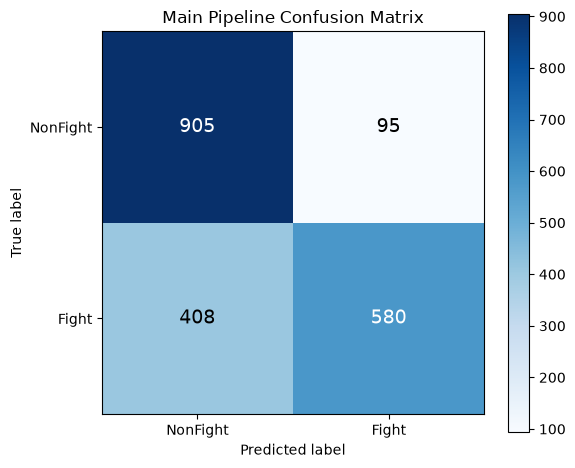

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm, cmap="Blues")
fig.colorbar(image, ax=ax)

labels = ["NonFight", "Fight"]
ax.set_xticks(np.arange(2), labels=labels)
ax.set_yticks(np.arange(2), labels=labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Main Pipeline Confusion Matrix")

threshold = cm.max() / 2 if cm.size and cm.max() else 0
for row in range(2):
    for col in range(2):
        color = "white" if cm[row, col] > threshold else "black"
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color=color, fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
wrong_results = [item for item in valid_results if not item["correct"]]
wrong_results[:20]

[{'path': 'dataset/RWF-2000/train/NonFight/0TP13Nyn_0.avi',
  'true_label': 0,
  'pred_label': 1,
  'correct': False,
  'frames_used': 150,
  'max_risk': 67.3,
  'mean_risk': 28.299,
  'alert_frames': 1,
  'error': ''},
 {'path': 'dataset/RWF-2000/train/NonFight/0_DzLlklZa0_2.avi',
  'true_label': 0,
  'pred_label': 1,
  'correct': False,
  'frames_used': 150,
  'max_risk': 69.9,
  'mean_risk': 45.455,
  'alert_frames': 7,
  'error': ''},
 {'path': 'dataset/RWF-2000/train/NonFight/18xQQOv5_0.avi',
  'true_label': 0,
  'pred_label': 1,
  'correct': False,
  'frames_used': 150,
  'max_risk': 73.7,
  'mean_risk': 40.663,
  'alert_frames': 9,
  'error': ''},
 {'path': 'dataset/RWF-2000/train/NonFight/1tU4kxa51vw_2.avi',
  'true_label': 0,
  'pred_label': 1,
  'correct': False,
  'frames_used': 150,
  'max_risk': 73.4,
  'mean_risk': 32.499,
  'alert_frames': 7,
  'error': ''},
 {'path': 'dataset/RWF-2000/train/NonFight/2KMf6p5Q_0.avi',
  'true_label': 0,
  'pred_label': 1,
  'correct': Fal